In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Konfigurera visning
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

# Ladda data
df = pd.read_csv('../data/Automobile_data.csv')

# Första kollen
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

Dataset shape: (205, 26)

First 5 rows:
   symboling normalized-losses         make fuel-type aspiration num-of-doors  \
0          3                 ?  alfa-romero       gas        std          two   
1          3                 ?  alfa-romero       gas        std          two   
2          1                 ?  alfa-romero       gas        std          two   
3          2               164         audi       gas        std         four   
4          2               164         audi       gas        std         four   

    body-style drive-wheels engine-location  wheel-base  length  width  \
0  convertible          rwd           front        88.6   168.8   64.1   
1  convertible          rwd           front        88.6   168.8   64.1   
2    hatchback          rwd           front        94.5   171.2   65.5   
3        sedan          fwd           front        99.8   176.6   66.2   
4        sedan          4wd           front        99.4   176.6   66.4   

   height  curb-weight engin

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  205 non-null    str    
 2   make               205 non-null    str    
 3   fuel-type          205 non-null    str    
 4   aspiration         205 non-null    str    
 5   num-of-doors       205 non-null    str    
 6   body-style         205 non-null    str    
 7   drive-wheels       205 non-null    str    
 8   engine-location    205 non-null    str    
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    str    
 15  num-of-cylinders   205 non-null    str    
 16  engine-size        205 non-null    in

In [5]:
# Cell 3: Statistisk sammanfattning
df.describe()

,symboling,wheel-base,length,width,height,curb-weight,engine-size,compression-ratio,city-mpg,highway-mpg
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,10.142537,25.219512,30.751220
std,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,3.972040,6.542142,6.886443
min,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,7.000000,13.000000,16.000000
25%,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,8.600000,19.000000,25.000000
50%,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,9.000000,24.000000,30.000000
75%,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,9.400000,30.000000,34.000000
max,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,23.000000,49.000000,54.000000


In [6]:
# Cell 4: Kolla hur många "?" vi har (saknade värden)
print("Saknade värden (som '?'):")
for col in df.columns:
    missing = (df[col] == '?').sum()
    if missing > 0:
        print(f"  {col}: {missing}")

Saknade värden (som '?'):
  normalized-losses: 41
  num-of-doors: 2
  bore: 4
  stroke: 4
  horsepower: 2
  peak-rpm: 2
  price: 4


In [7]:
# Cell 5: Kolla dubbletter
print(f"Antal dubbletter: {df.duplicated().sum()}")
print(f"\nAntal unika bilmärken: {df['make'].nunique()}")
print(df['make'].value_counts().head(10))

Antal dubbletter: 0

Antal unika bilmärken: 22
make
toyota        32
nissan        18
mazda         17
honda         13
mitsubishi    13
subaru        12
volkswagen    12
peugot        11
volvo         11
dodge          9
Name: count, dtype: int64


In [8]:
# Cell 6: Datarening - Steg 1
# Skapa en kopia av original data (bra practice att ha original kvar)
df_clean = df.copy()

# Ersätt alla "?" med NaN (Not a Number)
df_clean = df_clean.replace('?', np.nan)

# Verifiera
print("Saknade värden (NaN) per kolumn:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

Saknade värden (NaN) per kolumn:
normalized-losses    41
num-of-doors          2
bore                  4
stroke                4
horsepower            2
peak-rpm              2
price                 4
dtype: int64


In [9]:
# Cell 7: Datarening - Steg 2
# Ta bort rader där price saknas
print(f"Före: {len(df_clean)} rader")
df_clean = df_clean.dropna(subset=['price'])
print(f"Efter: {len(df_clean)} rader")
print(f"Borttagna rader: {205 - len(df_clean)}")

# Verifiera att price inte har NaN längre
print(f"\nPrice saknade värden: {df_clean['price'].isnull().sum()}")

Före: 205 rader
Efter: 201 rader
Borttagna rader: 4

Price saknade värden: 0


In [10]:
# Cell 8: Datarening - Steg 3
# Konvertera kolumner till numeriska datatypes
numeric_cols = ['normalized-losses', 'bore', 'stroke', 'horsepower', 'peak-rpm', 'price']

for col in numeric_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# Verifiera datatypes
print("Datatypes efter konvertering:")
print(df_clean[numeric_cols].dtypes)
print("\nSaknade värden kvar:")
print(df_clean[numeric_cols].isnull().sum())

Datatypes efter konvertering:
normalized-losses    float64
bore                 float64
stroke               float64
horsepower           float64
peak-rpm             float64
price                  int64
dtype: object

Saknade värden kvar:
normalized-losses    37
bore                  4
stroke                4
horsepower            2
peak-rpm              2
price                 0
dtype: int64


In [12]:
# Cell 9: Datarening - Steg 4 (FIXED)
# Imputera numeriska kolumner med median
numeric_impute_cols = ['normalized-losses', 'bore', 'stroke', 'horsepower', 'peak-rpm']

for col in numeric_impute_cols:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)  # ÄNDRING: Utan inplace
    print(f"{col}: imputerade med median = {median_val:.2f}")

# Imputera num-of-doors med mode (vanligaste värdet)
mode_val = df_clean['num-of-doors'].mode()[0]
df_clean['num-of-doors'] = df_clean['num-of-doors'].fillna(mode_val)  # ÄNDRING: Utan inplace
print(f"\nnum-of-doors: imputerade med mode = '{mode_val}'")

# Verifiera att allt är rensat
print(f"\nTotala saknade värden kvar: {df_clean.isnull().sum().sum()}")

normalized-losses: imputerade med median = 115.00
bore: imputerade med median = 3.31
stroke: imputerade med median = 3.29
horsepower: imputerade med median = 95.00
peak-rpm: imputerade med median = 5200.00

num-of-doors: imputerade med mode = 'four'

Totala saknade värden kvar: 0


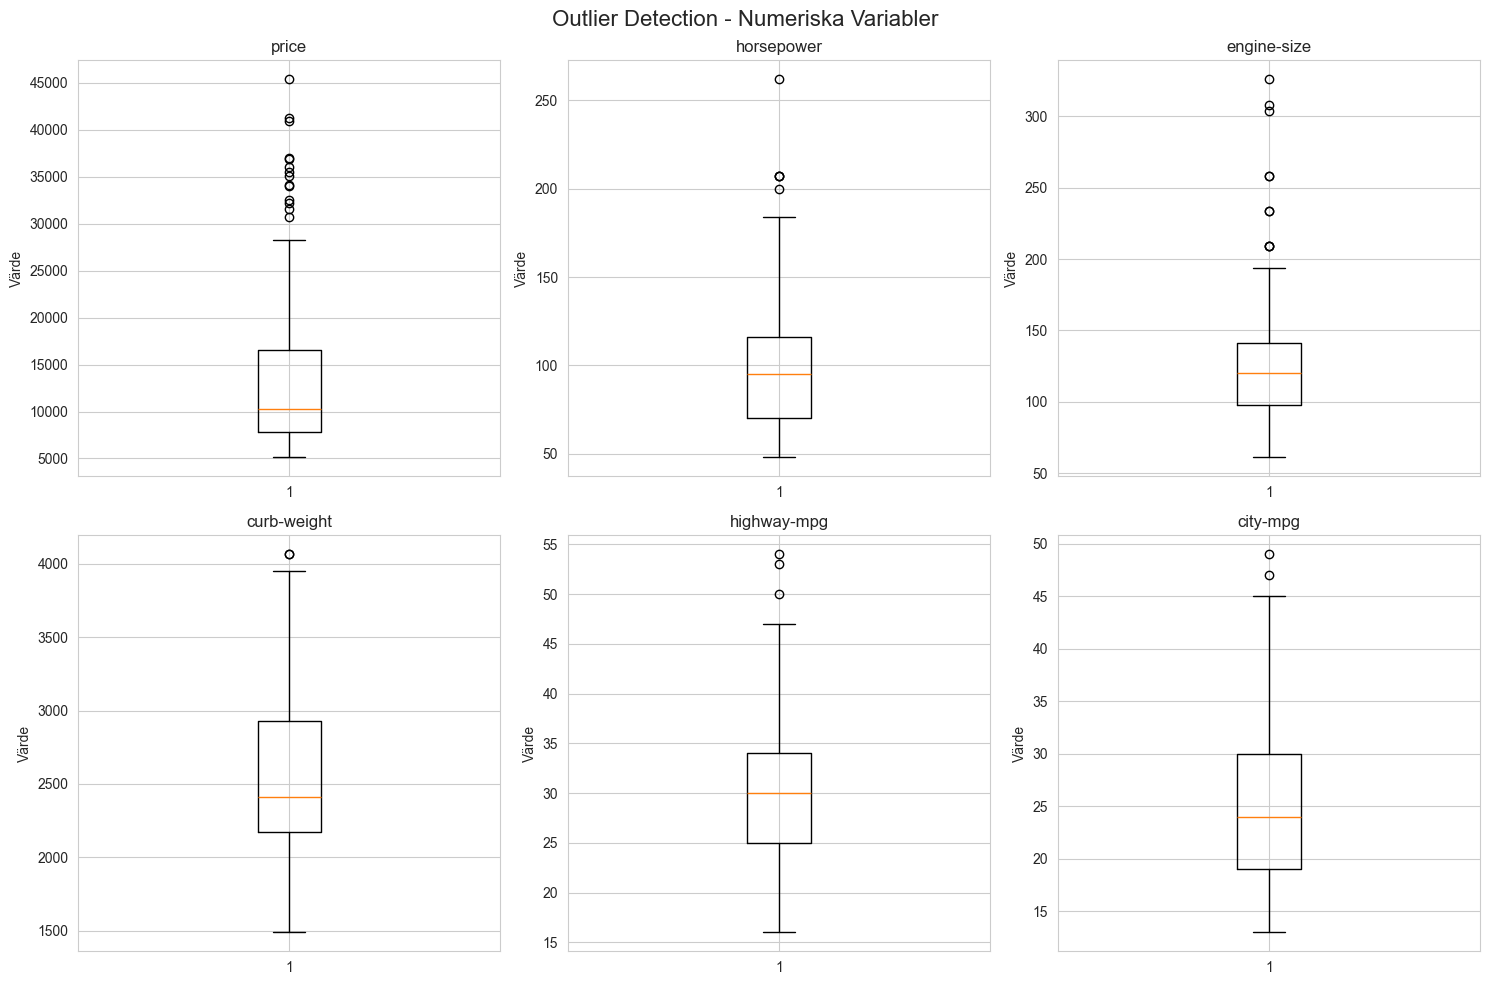

Price statistik:
count      201.000000
mean     13207.129353
std       7947.066342
min       5118.000000
25%       7775.000000
50%      10295.000000
75%      16500.000000
max      45400.000000
Name: price, dtype: float64


In [13]:
# Cell 10: Kolla outliers med boxplot
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Outlier Detection - Numeriska Variabler', fontsize=16)

# Viktiga numeriska kolumner att visualisera
numeric_vars = ['price', 'horsepower', 'engine-size', 'curb-weight', 'highway-mpg', 'city-mpg']

for idx, col in enumerate(numeric_vars):
    row = idx // 3
    col_idx = idx % 3
    axes[row, col_idx].boxplot(df_clean[col].dropna())
    axes[row, col_idx].set_title(col)
    axes[row, col_idx].set_ylabel('Värde')

plt.tight_layout()
plt.show()

# Kolla statistik för price (vår target)
print("Price statistik:")
print(df_clean['price'].describe())

In [14]:
# Cell 11: Spara renad data
df_clean.to_csv('../data/Automobile_data_clean.csv', index=False)
print(f"✅ Renad data sparad!")
print(f"Original: 205 rader → Renad: {len(df_clean)} rader")
print(f"Saknade värden: {df_clean.isnull().sum().sum()}")

✅ Renad data sparad!
Original: 205 rader → Renad: 201 rader
Saknade värden: 0


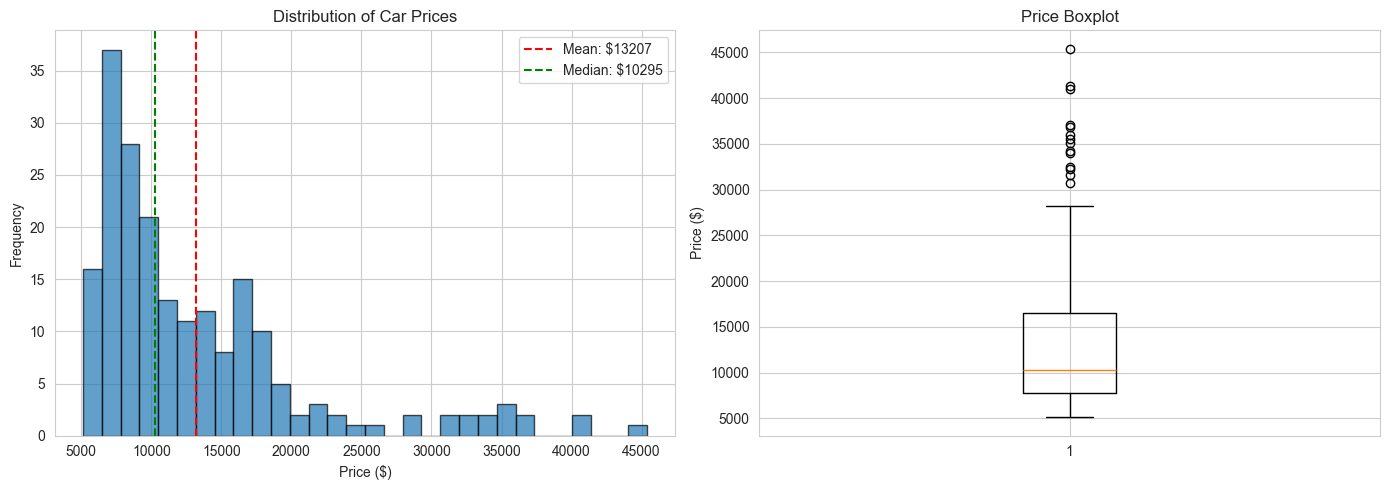

Price statistik:
Mean: $13207.13
Median: $10295.00
Std: $7947.07


In [15]:
# Cell 12: EDA - Price distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df_clean['price'], bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Car Prices')
axes[0].axvline(df_clean['price'].mean(), color='red', linestyle='--', label=f'Mean: ${df_clean["price"].mean():.0f}')
axes[0].axvline(df_clean['price'].median(), color='green', linestyle='--', label=f'Median: ${df_clean["price"].median():.0f}')
axes[0].legend()

# Boxplot
axes[1].boxplot(df_clean['price'])
axes[1].set_ylabel('Price ($)')
axes[1].set_title('Price Boxplot')

plt.tight_layout()
plt.show()

print(f"Price statistik:\nMean: ${df_clean['price'].mean():.2f}\nMedian: ${df_clean['price'].median():.2f}\nStd: ${df_clean['price'].std():.2f}")

Korrelation med Price:
price                1.000000
engine-size          0.872335
curb-weight          0.834415
horsepower           0.810500
width                0.751265
length               0.690628
wheel-base           0.584642
bore                 0.543158
height               0.135486
normalized-losses    0.094366
stroke               0.082209
compression-ratio    0.071107
symboling           -0.082391
peak-rpm            -0.102310
city-mpg            -0.686571
highway-mpg         -0.704692
Name: price, dtype: float64


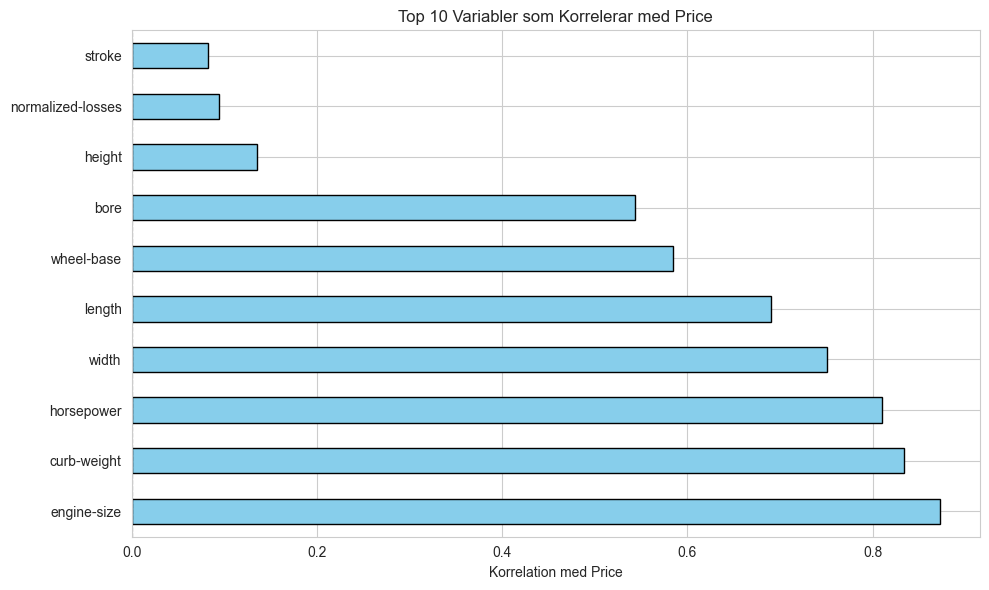

In [16]:
# Cell 13: EDA - Korrelation med price
# Välj numeriska kolumner
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()

# Beräkna korrelation med price
correlations = df_clean[numeric_cols].corr()['price'].sort_values(ascending=False)
print("Korrelation med Price:")
print(correlations)

# Visualisera top korrelationer
top_corr = correlations.drop('price').head(10)  # Top 10 (exklusive price själv)

plt.figure(figsize=(10, 6))
top_corr.plot(kind='barh', color='skyblue', edgecolor='black')
plt.xlabel('Korrelation med Price')
plt.title('Top 10 Variabler som Korrelerar med Price')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

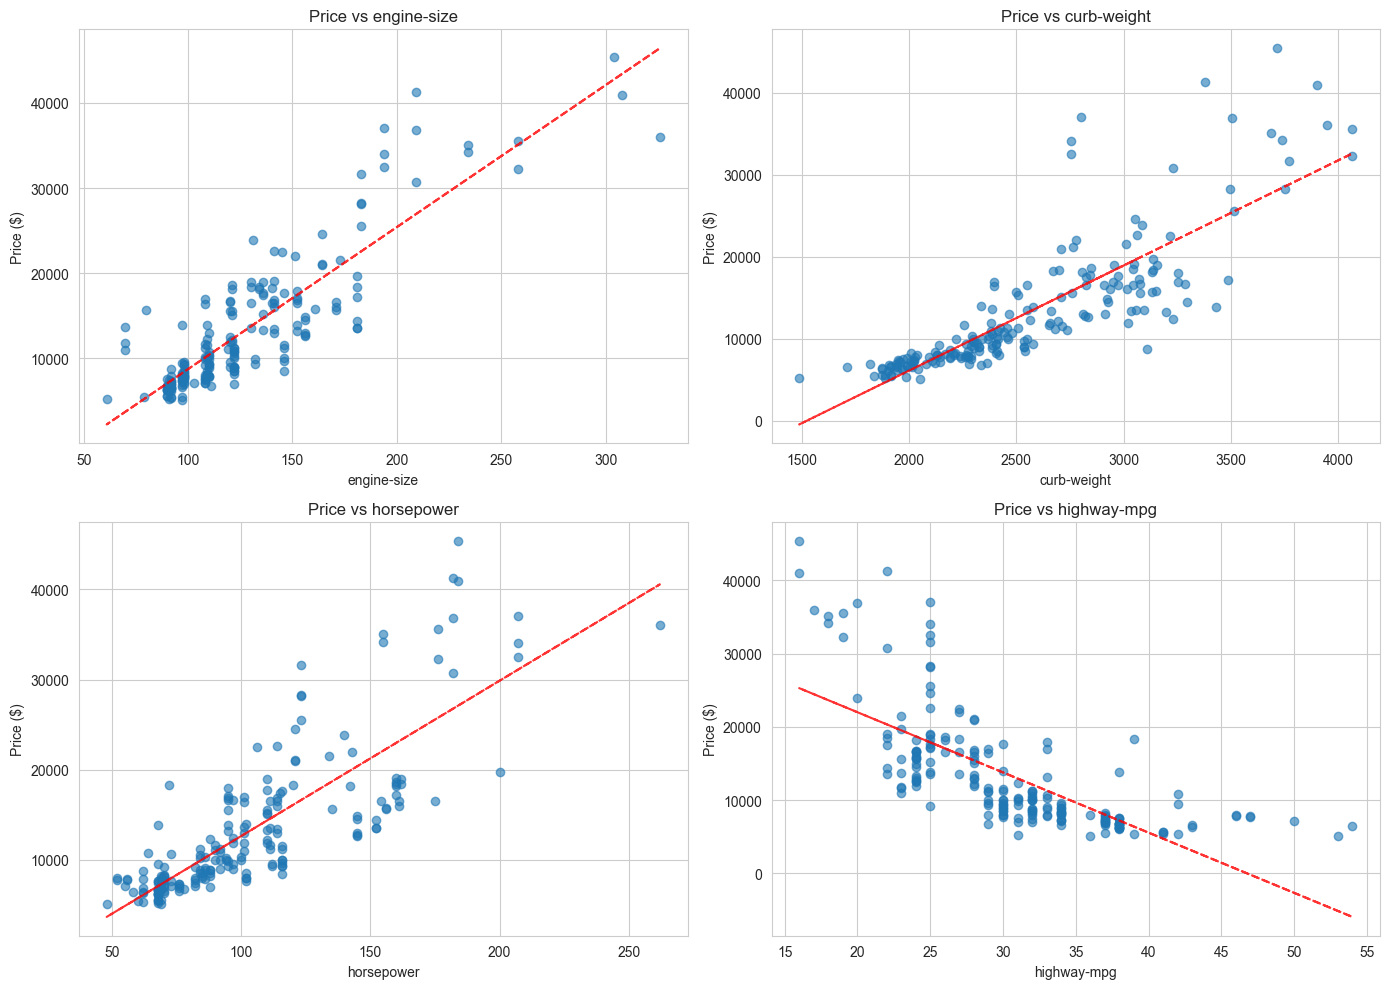

In [17]:
# Cell 14: EDA - Scatter plots för top korrelationer
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top 4 korrelationer
top_vars = ['engine-size', 'curb-weight', 'horsepower', 'highway-mpg']

for idx, var in enumerate(top_vars):
    row = idx // 2
    col = idx % 2
    axes[row, col].scatter(df_clean[var], df_clean['price'], alpha=0.6)
    axes[row, col].set_xlabel(var)
    axes[row, col].set_ylabel('Price ($)')
    axes[row, col].set_title(f'Price vs {var}')
    
    # Lägg till trendlinje
    z = np.polyfit(df_clean[var], df_clean['price'], 1)
    p = np.poly1d(z)
    axes[row, col].plot(df_clean[var], p(df_clean[var]), "r--", alpha=0.8)

plt.tight_layout()
plt.show()

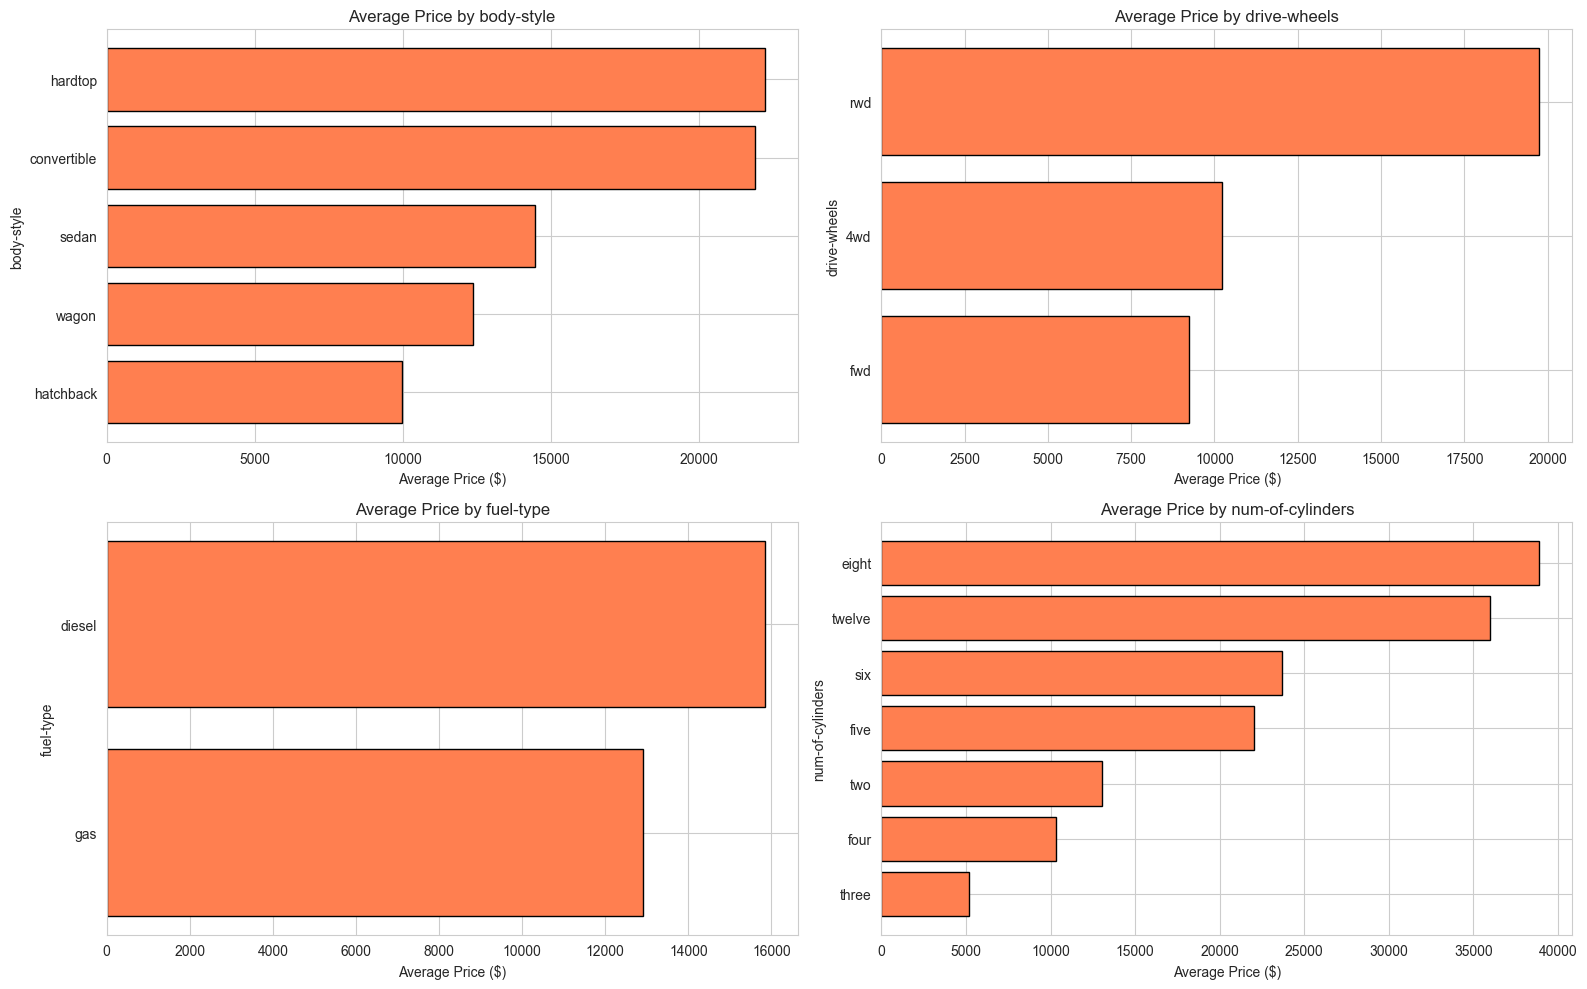


Price by body-style:
                     mean  count
body-style                      
convertible  21890.500000    6.0
hardtop      22208.500000    8.0
hatchback     9957.441176   68.0
sedan        14459.755319   94.0
wagon        12371.960000   25.0


In [18]:
# Cell 15: EDA - Kategoriska variabler vs Price
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Viktiga kategoriska variabler
cat_vars = ['body-style', 'drive-wheels', 'fuel-type', 'num-of-cylinders']

for idx, var in enumerate(cat_vars):
    row = idx // 2
    col = idx % 2
    
    # Gruppera och beräkna mean price per kategori
    grouped = df_clean.groupby(var)['price'].mean().sort_values()
    
    axes[row, col].barh(grouped.index, grouped.values, color='coral', edgecolor='black')
    axes[row, col].set_xlabel('Average Price ($)')
    axes[row, col].set_ylabel(var)
    axes[row, col].set_title(f'Average Price by {var}')

plt.tight_layout()
plt.show()

# Visa statistik för body-style (exempel)
print("\nPrice by body-style:")
print(df_clean.groupby('body-style')['price'].describe()[['mean', 'count']])

In [19]:
# Cell 16: Hypotestestning - ANOVA för kategoriska variabler
from scipy import stats

print("=== HYPOTESTESTNING ===\n")

# Test 1: ANOVA - Skiljer sig price mellan olika body-styles?
body_groups = [df_clean[df_clean['body-style'] == style]['price'].values 
               for style in df_clean['body-style'].unique()]
f_stat, p_value = stats.f_oneway(*body_groups)
print(f"ANOVA: Price vs body-style")
print(f"F-statistic: {f_stat:.2f}, p-value: {p_value:.4f}")
print(f"Resultat: {'SIGNIFIKANT' if p_value < 0.05 else 'EJ SIGNIFIKANT'} (p < 0.05)\n")

# Test 2: T-test - Skiljer sig price mellan gas vs diesel?
gas_prices = df_clean[df_clean['fuel-type'] == 'gas']['price']
diesel_prices = df_clean[df_clean['fuel-type'] == 'diesel']['price']
t_stat, p_value = stats.ttest_ind(gas_prices, diesel_prices)
print(f"T-test: Price Gas vs Diesel")
print(f"T-statistic: {t_stat:.2f}, p-value: {p_value:.4f}")
print(f"Resultat: {'SIGNIFIKANT' if p_value < 0.05 else 'EJ SIGNIFIKANT'} (p < 0.05)")

=== HYPOTESTESTNING ===

ANOVA: Price vs body-style
F-statistic: 9.13, p-value: 0.0000
Resultat: SIGNIFIKANT (p < 0.05)

T-test: Price Gas vs Diesel
T-statistic: -1.57, p-value: 0.1190
Resultat: EJ SIGNIFIKANT (p < 0.05)


In [20]:
# Cell 17: Linjär Regression - engine-size vs price
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, r2_score

# Förbered data för regression
X = df_clean['engine-size']  # Prediktor
y = df_clean['price']  # Target

# Lägg till konstant (intercept)
X_with_const = sm.add_constant(X)

# Bygg modellen
model = sm.OLS(y, X_with_const).fit()

# Visa sammanfattning
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.761
Model:                            OLS   Adj. R-squared:                  0.760
Method:                 Least Squares   F-statistic:                     633.5
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           9.27e-64
Time:                        11:37:59   Log-Likelihood:                -1946.0
No. Observations:                 201   AIC:                             3896.
Df Residuals:                     199   BIC:                             3903.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const       -7963.3389    884.835     -9.000      

=== MODELL UTVÄRDERING ===
R² (R-squared): 0.7610
MSE (Mean Squared Error): 15021126.03
RMSE (Root Mean Squared Error): 3875.71

Tolkning: Modellen har i genomsnitt ett fel på ±$3876 när den förutsäger price


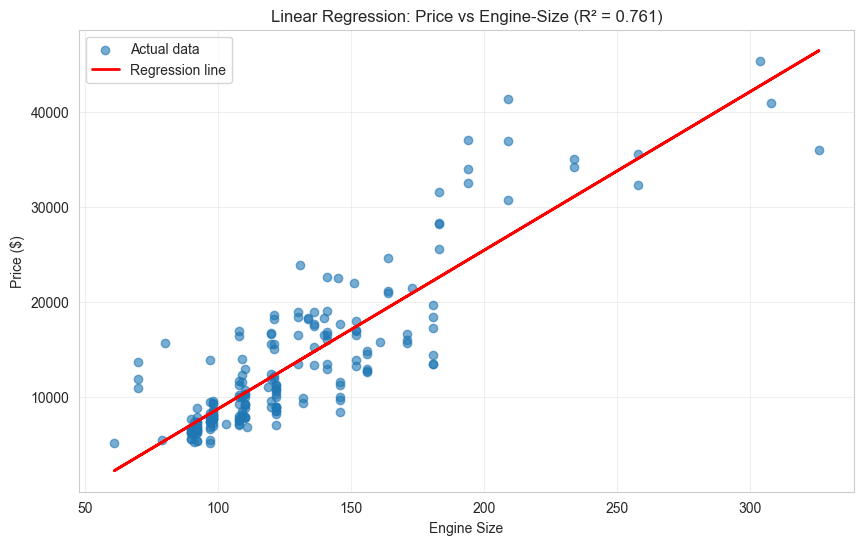

In [21]:
# Cell 18: Utvärdera modellen med MSE, RMSE och visualisering
from sklearn.metrics import mean_squared_error
import numpy as np

# Förutsägelser
y_pred = model.predict(X_with_const)

# Beräkna metrics
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y, y_pred)

print("=== MODELL UTVÄRDERING ===")
print(f"R² (R-squared): {r2:.4f}")
print(f"MSE (Mean Squared Error): {mse:.2f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.2f}")
print(f"\nTolkning: Modellen har i genomsnitt ett fel på ±${rmse:.0f} när den förutsäger price")

# Visualisera regression
plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.6, label='Actual data')
plt.plot(X, y_pred, color='red', linewidth=2, label='Regression line')
plt.xlabel('Engine Size')
plt.ylabel('Price ($)')
plt.title(f'Linear Regression: Price vs Engine-Size (R² = {r2:.3f})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

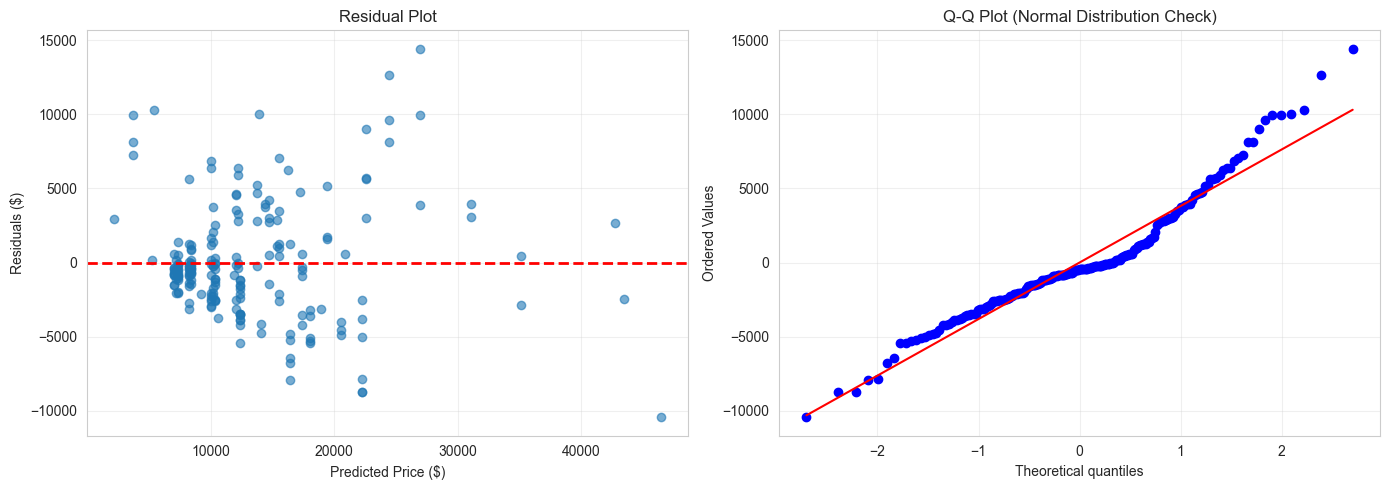

Residuals Mean: 0.00 (bör vara nära 0)
Residuals Std: 3885.39


In [22]:
# Cell 19: Residual-analys
residuals = y - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Residual plot (ska vara slumpmässigt fördelad runt 0)
axes[0].scatter(y_pred, residuals, alpha=0.6)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Predicted Price ($)')
axes[0].set_ylabel('Residuals ($)')
axes[0].set_title('Residual Plot')
axes[0].grid(True, alpha=0.3)

# 2. Q-Q plot (normalfördelning av residuals)
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot (Normal Distribution Check)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Residuals Mean: {residuals.mean():.2f} (bör vara nära 0)")
print(f"Residuals Std: {residuals.std():.2f}")

In [23]:
# Cell 20: Spara ALLA figurer till output mappen
import os

# Skapa output mapp
os.makedirs('../output', exist_ok=True)
print("Sparar figurer till ../output/\n")

# ===== FIGUR 1: Price Distribution =====
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df_clean['price'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Price ($)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Car Prices', fontsize=14, fontweight='bold')
axes[0].axvline(df_clean['price'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: ${df_clean["price"].mean():.0f}')
axes[0].axvline(df_clean['price'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: ${df_clean["price"].median():.0f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].boxplot(df_clean['price'], patch_artist=True, 
                boxprops=dict(facecolor='lightblue', color='black'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_ylabel('Price ($)', fontsize=12)
axes[1].set_title('Price Boxplot', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../output/01_price_distribution.png', dpi=300, bbox_inches='tight')
plt.close()
print("✓ 01_price_distribution.png")

# ===== FIGUR 2: Korrelation med Price =====
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
correlations = df_clean[numeric_cols].corr()['price'].sort_values(ascending=False)
top_corr = correlations.drop('price').head(10)

plt.figure(figsize=(10, 6))
colors = ['green' if x > 0 else 'red' for x in top_corr.values]
top_corr.plot(kind='barh', color=colors, edgecolor='black')
plt.xlabel('Korrelation med Price', fontsize=12)
plt.ylabel('Variabel', fontsize=12)
plt.title('Top 10 Variabler som Korrelerar med Price', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('../output/02_correlation.png', dpi=300, bbox_inches='tight')
plt.close()
print("✓ 02_correlation.png")

# ===== FIGUR 3: Scatter Plots (Top 4 korrelationer) =====
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
top_vars = ['engine-size', 'curb-weight', 'horsepower', 'highway-mpg']

for idx, var in enumerate(top_vars):
    row = idx // 2
    col = idx % 2
    axes[row, col].scatter(df_clean[var], df_clean['price'], alpha=0.6, s=50, color='steelblue', edgecolors='black')
    axes[row, col].set_xlabel(var, fontsize=12)
    axes[row, col].set_ylabel('Price ($)', fontsize=12)
    axes[row, col].set_title(f'Price vs {var}', fontsize=13, fontweight='bold')
    axes[row, col].grid(True, alpha=0.3)
    
    # Trendlinje
    z = np.polyfit(df_clean[var], df_clean['price'], 1)
    p = np.poly1d(z)
    axes[row, col].plot(df_clean[var], p(df_clean[var]), "r--", alpha=0.8, linewidth=2)

plt.tight_layout()
plt.savefig('../output/03_scatter_plots.png', dpi=300, bbox_inches='tight')
plt.close()
print("✓ 03_scatter_plots.png")

# ===== FIGUR 4: Kategoriska Variabler =====
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
cat_vars = ['body-style', 'drive-wheels', 'fuel-type', 'num-of-cylinders']

for idx, var in enumerate(cat_vars):
    row = idx // 2
    col_idx = idx % 2
    
    grouped = df_clean.groupby(var)['price'].mean().sort_values()
    
    axes[row, col_idx].barh(grouped.index, grouped.values, color='coral', edgecolor='black')
    axes[row, col_idx].set_xlabel('Average Price ($)', fontsize=12)
    axes[row, col_idx].set_ylabel(var, fontsize=12)
    axes[row, col_idx].set_title(f'Average Price by {var}', fontsize=13, fontweight='bold')
    axes[row, col_idx].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('../output/04_categorical_analysis.png', dpi=300, bbox_inches='tight')
plt.close()
print("✓ 04_categorical_analysis.png")

# ===== FIGUR 5: Regression (engine-size vs price) =====
X = df_clean['engine-size']
y = df_clean['price']
X_with_const = sm.add_constant(X)
model = sm.OLS(y, X_with_const).fit()
y_pred = model.predict(X_with_const)

plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.6, s=50, color='steelblue', edgecolors='black', label='Actual data')
plt.plot(X, y_pred, color='red', linewidth=2, label='Regression line')
plt.xlabel('Engine Size', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.title(f'Linear Regression: Price vs Engine-Size (R² = {model.rsquared:.3f})', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../output/05_regression.png', dpi=300, bbox_inches='tight')
plt.close()
print("✓ 05_regression.png")

# ===== FIGUR 6: Residual Analysis =====
residuals = y - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residual plot
axes[0].scatter(y_pred, residuals, alpha=0.6, s=50, color='steelblue', edgecolors='black')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Predicted Price ($)', fontsize=12)
axes[0].set_ylabel('Residuals ($)', fontsize=12)
axes[0].set_title('Residual Plot', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Q-Q plot
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot (Normal Distribution Check)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../output/06_residual_analysis.png', dpi=300, bbox_inches='tight')
plt.close()
print("✓ 06_residual_analysis.png")

# ===== FIGUR 7: Outlier Detection =====
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Outlier Detection - Numeriska Variabler', fontsize=16, fontweight='bold')

numeric_vars = ['price', 'horsepower', 'engine-size', 'curb-weight', 'highway-mpg', 'city-mpg']

for idx, col in enumerate(numeric_vars):
    row = idx // 3
    col_idx = idx % 3
    bp = axes[row, col_idx].boxplot(df_clean[col].dropna(), patch_artist=True,
                                     boxprops=dict(facecolor='lightblue', color='black'),
                                     medianprops=dict(color='red', linewidth=2))
    axes[row, col_idx].set_title(col, fontsize=12, fontweight='bold')
    axes[row, col_idx].set_ylabel('Värde', fontsize=11)
    axes[row, col_idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../output/07_outliers.png', dpi=300, bbox_inches='tight')
plt.close()
print("✓ 07_outliers.png")

print("\n✅ ALLA FIGURER SPARADE!")
print(f"Total: 7 figurer i '../output/' mappen")

Sparar figurer till ../output/

✓ 01_price_distribution.png
✓ 02_correlation.png
✓ 03_scatter_plots.png
✓ 04_categorical_analysis.png
✓ 05_regression.png
✓ 06_residual_analysis.png
✓ 07_outliers.png

✅ ALLA FIGURER SPARADE!
Total: 7 figurer i '../output/' mappen
